In [3]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import os
import re
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [4]:
print("=" * 50)
print("Environment Information")
print("=" * 50)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

Environment Information
NumPy : 2.3.1
Pandas: 2.3.0


In [5]:
# ================================
# DATASET PATHS
# ================================

BASE_DIR = "../data"

GOEMOTIONS_PATH = os.path.join(BASE_DIR, "GoEmotions")
ISEAR_PATH = os.path.join(BASE_DIR, "ISEAR Dataset")
EMPATHY_PATH = os.path.join(BASE_DIR, "empatheticdialogues")
EMOCONTEXT_PATH = os.path.join(BASE_DIR, "cleaned_emocontext")

print("GoEmotions :", GOEMOTIONS_PATH)
print("ISEAR      :", ISEAR_PATH)
print("Empathetic :", EMPATHY_PATH)
print("EmoContext :", EMOCONTEXT_PATH)

GoEmotions : ../data\GoEmotions
ISEAR      : ../data\ISEAR Dataset
Empathetic : ../data\empatheticdialogues
EmoContext : ../data\cleaned_emocontext


In [6]:
datasets = {
    "GoEmotions": GOEMOTIONS_PATH,
    "ISEAR": ISEAR_PATH,
    "EmpatheticDialogues": EMPATHY_PATH,
    "EmoContext": EMOCONTEXT_PATH,
}

for name, path in datasets.items():
    print(f"\n{name}")
    print("-" * 30)

    if os.path.exists(path):
        files = os.listdir(path)

        for file in files:
            print(file)

    else:
        print("❌ Folder Not Found")


GoEmotions
------------------------------
dev.tsv
ekman_labels.csv
ekman_mapping.json
emotions.txt
test.tsv
train.tsv

ISEAR
------------------------------
eng_dataset.csv

EmpatheticDialogues
------------------------------
emotion-emotion_69k.csv

EmoContext
------------------------------
dev.txt
devwithoutlabels.txt
testwithoutlabels.txt
train (1).txt


In [7]:
# =====================================
# LOAD GOEMOTIONS DATASET
# =====================================

go_train = pd.read_csv(
    os.path.join(GOEMOTIONS_PATH, "train.tsv"),
    sep="\t",
    header=None
)

go_dev = pd.read_csv(
    os.path.join(GOEMOTIONS_PATH, "dev.tsv"),
    sep="\t",
    header=None
)

go_test = pd.read_csv(
    os.path.join(GOEMOTIONS_PATH, "test.tsv"),
    sep="\t",
    header=None
)

print("Train Shape :", go_train.shape)
print("Dev Shape   :", go_dev.shape)
print("Test Shape  :", go_test.shape)

Train Shape : (43410, 3)
Dev Shape   : (5426, 3)
Test Shape  : (5427, 3)


In [8]:
go_train.columns = ["text", "label", "id"]
go_dev.columns = ["text", "label", "id"]
go_test.columns = ["text", "label", "id"]

go_train.head()

,text,label,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [9]:
print("="*60)
print("GOEMOTIONS INFORMATION")
print("="*60)

print("\nColumns:")
print(go_train.columns)

print("\nMissing Values:")
print(go_train.isnull().sum())

print("\nDuplicate Rows:")
print(go_train.duplicated().sum())

print("\nShape:")
print(go_train.shape)

GOEMOTIONS INFORMATION

Columns:
Index(['text', 'label', 'id'], dtype='object')

Missing Values:
text     0
label    0
id       0
dtype: int64

Duplicate Rows:
0

Shape:
(43410, 3)


In [10]:
go_train.sample(5)

,text,label,id
10391,"Oh, tosh, we all know there's #fakenews /s",27,edftxpz
41872,Will the real [NAME] please stand up?,27,eegkr4p
9715,"Interesting, thanks for clarifying.",15,edn5zbu
3001,"The ""richest"" country in the worlds royal pala...",18,ee53bo9
26075,Expectations was amazing - this ain’t it,0,eds6p71


In [11]:
print("Unique Labels:")

print(go_train["label"].nunique())

print("\nSample Labels:")

print(sorted(go_train["label"].unique())[:20])

Unique Labels:
711

Sample Labels:
['0', '0,1', '0,1,11', '0,1,12', '0,1,13', '0,1,17', '0,1,18', '0,1,4', '0,1,7', '0,10', '0,10,13', '0,10,15,22', '0,10,18', '0,11', '0,11,12', '0,11,20', '0,12,13,26', '0,13', '0,13,15', '0,13,17']


In [12]:
with open(os.path.join(GOEMOTIONS_PATH, "emotions.txt"), "r") as f:
    emotions = [line.strip() for line in f]

print("Number of emotions:", len(emotions))
print(emotions)

Number of emotions: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [13]:
print("Total Rows:", len(go_train))

single_label = go_train[~go_train["label"].str.contains(",")]

print("Single-label Rows:", len(single_label))

multi_label = go_train[go_train["label"].str.contains(",")]

print("Multi-label Rows:", len(multi_label))

Total Rows: 43410
Single-label Rows: 36308
Multi-label Rows: 7102


In [14]:
single_label.head()

,text,label,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [15]:
go_train_single = go_train[~go_train["label"].str.contains(",")].copy()

# Epic 1: Data Collection & Preprocessing

## 3. GoEmotions Dataset Analysis

### Objective
The GoEmotions dataset, developed by Google, contains Reddit comments annotated with 28 emotion categories. In this section, we explore the dataset, analyze its structure, identify multi-label samples, and prepare it for further preprocessing.

In [16]:
## 3.1 Load GoEmotions Dataset

## 3.2 Dataset Overview

## 3.3 Emotion Label Analysis

## 3.4 Single-label vs Multi-label Analysis

In [17]:
go_train_single = go_train[
    ~go_train["label"].str.contains(",")
].copy()

print("Original Dataset :", len(go_train))
print("Single Label Dataset :", len(go_train_single))

Original Dataset : 43410
Single Label Dataset : 36308


### Observation

The GoEmotions dataset contains both single-label and multi-label samples.

- Total Samples: **43,410**
- Single-label Samples: **36,308**
- Multi-label Samples: **7,102**

Since the target application predicts one primary emotion for each user input, only single-label samples are selected for the first version of the model. The original dataset is preserved for future multi-label experiments.

In [18]:
# Missing values
go_train_single.isnull().sum()

# Duplicate rows
go_train_single.duplicated().sum()

# Data types
go_train_single.info()

# Class distribution
go_train_single["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 36308 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    36308 non-null  object
 1   label   36308 non-null  object
 2   id      36308 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


label
27    12823
0      2710
4      1873
15     1857
1      1652
3      1451
18     1427
10     1402
7      1389
2      1025
20      861
6       858
17      853
25      817
26      720
9       709
5       649
22      586
13      510
11      498
14      430
8       389
24      353
12      203
23       88
19       85
21       51
16       39
Name: count, dtype: int64

## 3.5 Data Quality Analysis

### Observations

- The dataset contains **36,308 single-label samples**.
- No missing values were found.
- All columns have the correct data types.
- The dataset is highly imbalanced.
- The **neutral** class has the largest number of samples (12,823).
- The **grief** class has the fewest samples (39).

### Conclusion

The dataset is clean and suitable for preprocessing. However, the class imbalance should be considered during model training. Techniques such as class weighting or data augmentation may be explored in later stages if necessary.

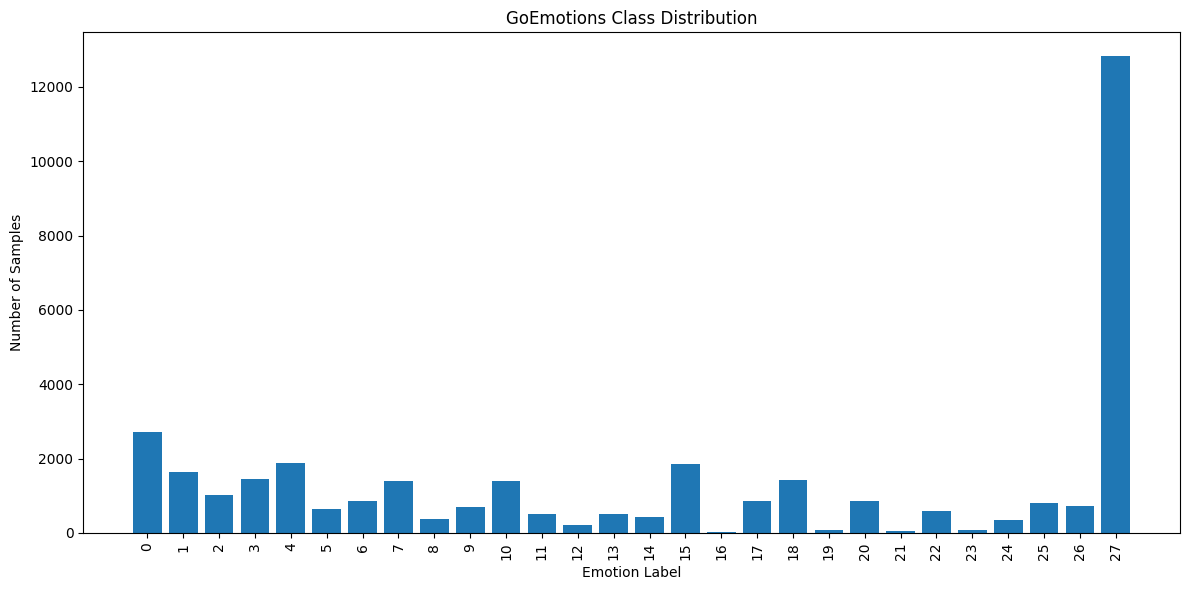

In [19]:
# =====================================
# GOEMOTIONS CLASS DISTRIBUTION
# =====================================

# Convert labels to integers for sorting
label_counts = (
    go_train_single["label"]
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.bar(label_counts.index.astype(str), label_counts.values)

plt.title("GoEmotions Class Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

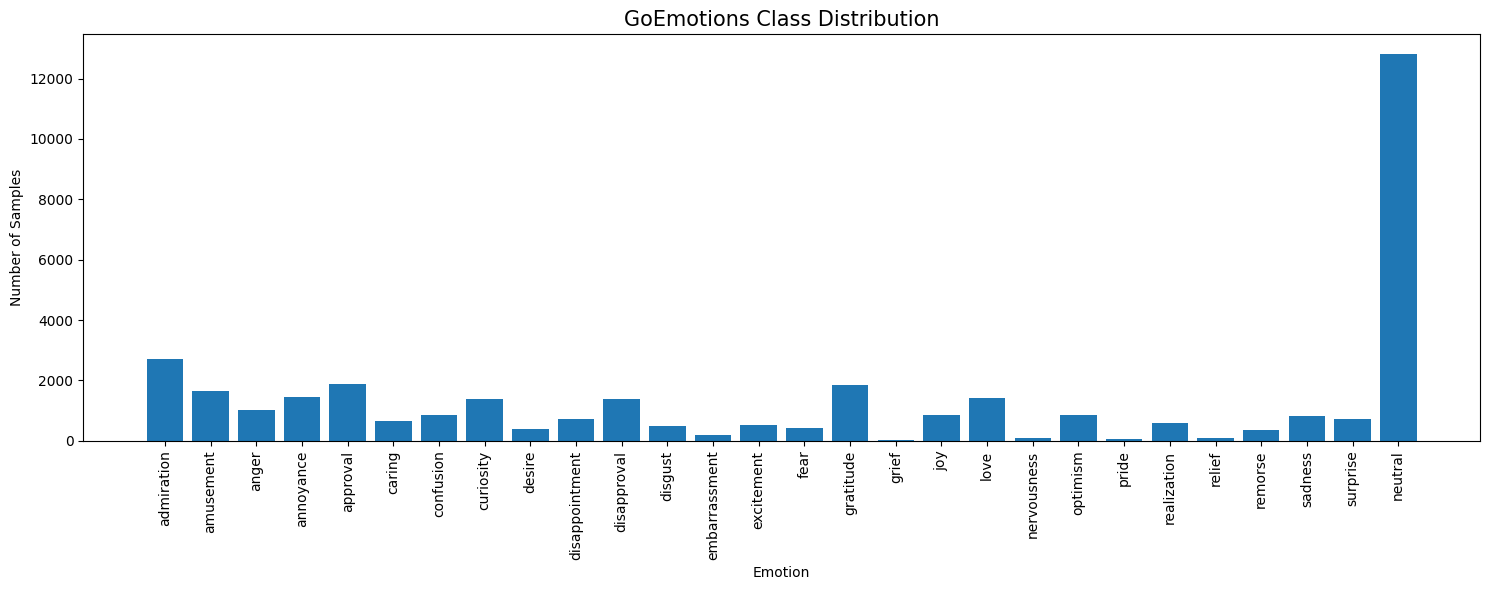

In [20]:
# =====================================
# GOEMOTIONS CLASS DISTRIBUTION
# =====================================

# Load emotion names
with open(os.path.join(GOEMOTIONS_PATH, "emotions.txt"), "r") as f:
    emotions = [line.strip() for line in f]

# Count labels
label_counts = (
    go_train_single["label"]
    .astype(int)
    .value_counts()
    .sort_index()
)

# Convert IDs to emotion names
emotion_names = [emotions[i] for i in label_counts.index]

plt.figure(figsize=(15,6))

plt.bar(emotion_names, label_counts.values)

plt.title("GoEmotions Class Distribution", fontsize=15)
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [21]:
# =====================================
# LOAD ISEAR DATASET
# =====================================

isear = pd.read_csv(
    os.path.join(ISEAR_PATH, "eng_dataset.csv")
)

print("ISEAR Shape:", isear.shape)

ISEAR Shape: (7102, 3)


In [22]:
isear.head()

,ID,sentiment,content
0,10941,anger,At the point today where if someone says somet...
1,10942,anger,@CorningFootball IT'S GAME DAY!!!! T MIN...
2,10943,anger,This game has pissed me off more than any othe...
3,10944,anger,@spamvicious I've just found out it's Candice ...
4,10945,anger,@moocowward @mrsajhargreaves @Melly77 @GaryBar...


In [23]:
print("="*60)
print("ISEAR DATASET INFORMATION")
print("="*60)

print("\nColumns:")
print(isear.columns.tolist())

print("\nMissing Values:")
print(isear.isnull().sum())

print("\nDuplicate Rows:")
print(isear.duplicated().sum())

print("\nData Types:")
print(isear.dtypes)

ISEAR DATASET INFORMATION

Columns:
['ID', 'sentiment', 'content']

Missing Values:
ID           0
sentiment    0
content      0
dtype: int64

Duplicate Rows:
0

Data Types:
ID            int64
sentiment    object
content      object
dtype: object


In [24]:
isear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7102 entries, 0 to 7101
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         7102 non-null   int64 
 1   sentiment  7102 non-null   object
 2   content    7102 non-null   object
dtypes: int64(1), object(2)
memory usage: 166.6+ KB


In [25]:
print("Emotion Distribution")

print(isear["sentiment"].value_counts())

Emotion Distribution
sentiment
fear       2252
anger      1701
joy        1616
sadness    1533
Name: count, dtype: int64


In [26]:
print(isear.columns.tolist())

['ID', 'sentiment', 'content']


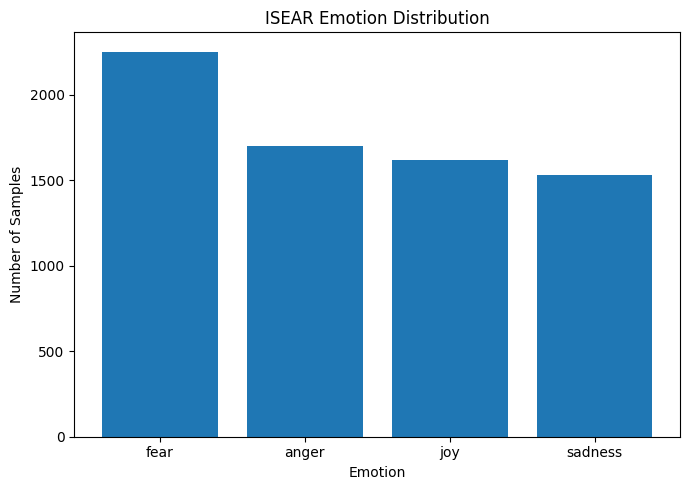

In [27]:
# =====================================
# ISEAR CLASS DISTRIBUTION
# =====================================

emotion_counts = isear["sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title("ISEAR Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.tight_layout()

plt.show()

In [28]:
# =====================================
# LOAD EMPATHETICDIALOGUES DATASET
# =====================================

empathy = pd.read_csv(
    os.path.join(EMPATHY_PATH, "emotion-emotion_69k.csv")
)

print("EmpatheticDialogues Shape:", empathy.shape)

EmpatheticDialogues Shape: (64636, 7)


In [29]:
empathy.head()

,Unnamed: 0,Situation,emotion,empathetic_dialogues,labels,Unnamed: 5,Unnamed: 6
0,0,I remember going to the fireworks with my best...,sentimental,Customer :I remember going to see the firework...,"Was this a friend you were in love with, or ju...",NaN,NaN
1,1,I remember going to the fireworks with my best...,sentimental,Customer :This was a best friend. I miss her.\...,Where has she gone?,NaN,NaN
2,2,I remember going to the fireworks with my best...,sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of...,NaN,NaN
3,3,I remember going to the fireworks with my best...,sentimental,Customer :Was this a friend you were in love w...,This was a best friend. I miss her.,NaN,NaN
4,4,I remember going to the fireworks with my best...,sentimental,Customer :Where has she gone?\nAgent :,We no longer talk.,NaN,NaN


In [30]:
print("=" * 60)
print("EMPATHETICDIALOGUES DATASET INFORMATION")
print("=" * 60)

print("\nColumns:")
print(empathy.columns.tolist())

print("\nMissing Values:")
print(empathy.isnull().sum())

print("\nDuplicate Rows:")
print(empathy.duplicated().sum())

print("\nData Types:")
print(empathy.dtypes)

EMPATHETICDIALOGUES DATASET INFORMATION

Columns:
['Unnamed: 0', 'Situation', 'emotion', 'empathetic_dialogues', 'labels', 'Unnamed: 5', 'Unnamed: 6']

Missing Values:
Unnamed: 0                  0
Situation                   0
emotion                     4
empathetic_dialogues        0
labels                      0
Unnamed: 5              64523
Unnamed: 6              64631
dtype: int64

Duplicate Rows:
0

Data Types:
Unnamed: 0               int64
Situation               object
emotion                 object
empathetic_dialogues    object
labels                  object
Unnamed: 5              object
Unnamed: 6              object
dtype: object


In [31]:
empathy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64636 entries, 0 to 64635
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            64636 non-null  int64 
 1   Situation             64636 non-null  object
 2   emotion               64632 non-null  object
 3   empathetic_dialogues  64636 non-null  object
 4   labels                64636 non-null  object
 5   Unnamed: 5            113 non-null    object
 6   Unnamed: 6            5 non-null      object
dtypes: int64(1), object(6)
memory usage: 3.5+ MB


In [32]:
print(empathy.columns.tolist())

['Unnamed: 0', 'Situation', 'emotion', 'empathetic_dialogues', 'labels', 'Unnamed: 5', 'Unnamed: 6']


In [33]:
print(empathy["emotion"].value_counts())

emotion
surprised                                                                                                                                                                                         3295
excited                                                                                                                                                                                           2465
angry                                                                                                                                                                                             2296
proud                                                                                                                                                                                             2247
annoyed                                                                                                                                                                                           22

In [34]:
print("Total Unique Emotions:", empathy["emotion"].nunique())

print(sorted(empathy["emotion"].dropna().unique()))

Total Unique Emotions: 43
[' I really killed it!', " a boy.  I hear all these different labor stories that aren't exactly reassuring!  ", " but what I didn't know was that he was working in the next room with the door open.  He approached and asked what I had been saying.  I knew I was caught.  I was so disgusted with myself.  ", ' time to jump on the motorcycle and go cruising!', ' we were in a different country', '(', 'afraid', 'angry', 'annoyed', 'anticipating', 'anxious', 'apprehensive', 'ashamed', 'caring', 'confident', 'content', 'devastated', 'disappointed', 'disgusted', 'embarrassed', 'excited', 'faithful', 'furious', 'grateful', 'guilty', 'hopeful', 'impressed', 'jealous', 'joyful', 'lonely', "m so mad with my brother. He stole from me and didn't think I would notice. ", 'nostalgic', 'prepared', 'proud', 'sad', 'sentimental', 'surprised', 't believe I like the show Power so much. I was never really into shows like that', 't believe my daughter taught herself how to play the uk

In [35]:
print("Dataset Shape:", empathy.shape)

print("Missing emotion values:")
print(empathy["emotion"].isnull().sum())

Dataset Shape: (64636, 7)
Missing emotion values:
4


In [36]:
valid_emotions = [
    "afraid","angry","annoyed","anticipating","anxious",
    "apprehensive","ashamed","caring","confident",
    "content","devastated","disappointed","disgusted",
    "embarrassed","excited","faithful","furious",
    "grateful","guilty","hopeful","impressed",
    "jealous","joyful","lonely","nostalgic",
    "prepared","proud","sad","sentimental",
    "surprised","terrified","trusting"
]

invalid = empathy[
    ~empathy["emotion"].isin(valid_emotions)
]

print("Invalid Rows:", len(invalid))

invalid[["emotion"]].head(20)

Invalid Rows: 45


,emotion
1419,I really killed it!
1420,I really killed it!
1421,I really killed it!
1422,I really killed it!
2546,we were in a different country
2547,we were in a different country
2548,we were in a different country
3722,t even like scary things
3723,t even like scary things
3724,t even like scary things


In [37]:
# =====================================
# KEEP ONLY VALID EMOTIONS
# =====================================

valid_emotions = [
    "afraid",
    "angry",
    "annoyed",
    "anticipating",
    "anxious",
    "apprehensive",
    "ashamed",
    "caring",
    "confident",
    "content",
    "devastated",
    "disappointed",
    "disgusted",
    "embarrassed",
    "excited",
    "faithful",
    "furious",
    "grateful",
    "guilty",
    "hopeful",
    "impressed",
    "jealous",
    "joyful",
    "lonely",
    "nostalgic",
    "prepared",
    "proud",
    "sad",
    "sentimental",
    "surprised",
    "terrified",
    "trusting"
]

empathy_clean = empathy[
    empathy["emotion"].isin(valid_emotions)
].copy()

print("Original Dataset :", len(empathy))
print("Clean Dataset    :", len(empathy_clean))

Original Dataset : 64636
Clean Dataset    : 64591


In [38]:
print("Unique Emotions:", empathy_clean["emotion"].nunique())
print(sorted(empathy_clean["emotion"].unique()))

Unique Emotions: 32
['afraid', 'angry', 'annoyed', 'anticipating', 'anxious', 'apprehensive', 'ashamed', 'caring', 'confident', 'content', 'devastated', 'disappointed', 'disgusted', 'embarrassed', 'excited', 'faithful', 'furious', 'grateful', 'guilty', 'hopeful', 'impressed', 'jealous', 'joyful', 'lonely', 'nostalgic', 'prepared', 'proud', 'sad', 'sentimental', 'surprised', 'terrified', 'trusting']


In [39]:
# =====================================
# LOAD EMOCONTEXT TRAIN DATASET
# =====================================

emocontext = pd.read_csv(
    os.path.join(EMOCONTEXT_PATH, "train (1).txt"),
    sep="\t"
)

print("EmoContext Shape:", emocontext.shape)

EmoContext Shape: (30160, 5)


In [40]:
emocontext.head()

,id,turn1,turn2,turn3,label
0,0,Don't worry I'm girl,hmm how do I know if you are,What's ur name?,others
1,1,When did I?,saw many times i think -_-,No. I never saw you,angry
2,2,By,by Google Chrome,Where you live,others
3,3,U r ridiculous,I might be ridiculous but I am telling the truth.,U little disgusting whore,angry
4,4,Just for time pass,wt do u do 4 a living then,Maybe,others


In [41]:
print("=" * 60)
print("EMOCONTEXT DATASET INFORMATION")
print("=" * 60)

print("\nColumns:")
print(emocontext.columns.tolist())

print("\nMissing Values:")
print(emocontext.isnull().sum())

print("\nDuplicate Rows:")
print(emocontext.duplicated().sum())

print("\nData Types:")
print(emocontext.dtypes)

EMOCONTEXT DATASET INFORMATION

Columns:
['id', 'turn1', 'turn2', 'turn3', 'label']

Missing Values:
id       0
turn1    3
turn2    0
turn3    0
label    0
dtype: int64

Duplicate Rows:
0

Data Types:
id        int64
turn1    object
turn2    object
turn3    object
label    object
dtype: object


In [42]:
print(emocontext["label"].value_counts())

label
others    14948
angry      5506
sad        5463
happy      4243
Name: count, dtype: int64


In [43]:
print("Unique Labels:", emocontext["label"].nunique())

print(sorted(emocontext["label"].unique()))

Unique Labels: 4
['angry', 'happy', 'others', 'sad']


In [44]:
# ==========================================
# STANDARDIZE GOEMOTIONS DATASET
# ==========================================

go_standard = go_train_single.copy()

# Rename columns
go_standard = go_standard.rename(columns={
    "text": "text",
    "label": "label"
})

# Add source column
go_standard["source"] = "GoEmotions"

# Keep only required columns
go_standard = go_standard[["text", "label", "source"]]

print("GoEmotions Shape:", go_standard.shape)

go_standard.head()

GoEmotions Shape: (36308, 3)


,text,label,source
0,My favourite food is anything I didn't have to...,27,GoEmotions
1,"Now if he does off himself, everyone will thin...",27,GoEmotions
2,WHY THE FUCK IS BAYLESS ISOING,2,GoEmotions
3,To make her feel threatened,14,GoEmotions
4,Dirty Southern Wankers,3,GoEmotions


In [45]:
# ==========================================
# STANDARDIZE ISEAR DATASET
# ==========================================

isear_standard = isear.copy()

# Rename columns
isear_standard = isear_standard.rename(columns={
    "content": "text",
    "sentiment": "label"
})

# Add source
isear_standard["source"] = "ISEAR"

# Keep only required columns
isear_standard = isear_standard[["text", "label", "source"]]

print("ISEAR Shape:", isear_standard.shape)

isear_standard.head()

ISEAR Shape: (7102, 3)


,text,label,source
0,At the point today where if someone says somet...,anger,ISEAR
1,@CorningFootball IT'S GAME DAY!!!! T MIN...,anger,ISEAR
2,This game has pissed me off more than any othe...,anger,ISEAR
3,@spamvicious I've just found out it's Candice ...,anger,ISEAR
4,@moocowward @mrsajhargreaves @Melly77 @GaryBar...,anger,ISEAR


In [48]:
# ==========================================
# STANDARDIZE EMPATHETICDIALOGUES DATASET
# ==========================================

empathetic_standard = empathy_clean.copy()

# Rename columns
empathetic_standard = empathetic_standard.rename(columns={
    "Situation": "text",
    "emotion": "label"
})

# Add source
empathetic_standard["source"] = "EmpatheticDialogues"

# Keep only required columns
empathetic_standard = empathetic_standard[
    ["text", "label", "source"]
]

print("EmpatheticDialogues Shape:", empathetic_standard.shape)

empathetic_standard.head()

EmpatheticDialogues Shape: (64591, 3)


,text,label,source
0,I remember going to the fireworks with my best...,sentimental,EmpatheticDialogues
1,I remember going to the fireworks with my best...,sentimental,EmpatheticDialogues
2,I remember going to the fireworks with my best...,sentimental,EmpatheticDialogues
3,I remember going to the fireworks with my best...,sentimental,EmpatheticDialogues
4,I remember going to the fireworks with my best...,sentimental,EmpatheticDialogues


In [47]:
%who DataFrame

emocontext	 empathy	 empathy_clean	 go_dev	 go_standard	 go_test	 go_train	 go_train_single	 invalid	 
isear	 isear_standard	 multi_label	 single_label	 


In [49]:
# ==========================================
# STANDARDIZE EMOCONTEXT DATASET
# ==========================================

emocontext_standard = emocontext.copy()

# Fill missing values
emocontext_standard["turn1"] = emocontext_standard["turn1"].fillna("")
emocontext_standard["turn2"] = emocontext_standard["turn2"].fillna("")
emocontext_standard["turn3"] = emocontext_standard["turn3"].fillna("")

# Combine all conversation turns
emocontext_standard["text"] = (
    emocontext_standard["turn1"] + " " +
    emocontext_standard["turn2"] + " " +
    emocontext_standard["turn3"]
)

# Rename label column
emocontext_standard = emocontext_standard.rename(columns={
    "label": "label"
})

# Add source
emocontext_standard["source"] = "EmoContext"

# Keep required columns
emocontext_standard = emocontext_standard[
    ["text", "label", "source"]
]

print("EmoContext Shape:", emocontext_standard.shape)

emocontext_standard.head()

EmoContext Shape: (30160, 3)


,text,label,source
0,Don't worry I'm girl hmm how do I know if you...,others,EmoContext
1,When did I? saw many times i think -_- No. I n...,angry,EmoContext
2,By by Google Chrome Where you live,others,EmoContext
3,U r ridiculous I might be ridiculous but I am ...,angry,EmoContext
4,Just for time pass wt do u do 4 a living then ...,others,EmoContext


In [50]:
# ==========================================
# MERGE ALL STANDARDIZED DATASETS
# ==========================================

combined_dataset = pd.concat(
    [
        go_standard,
        isear_standard,
        empathetic_standard,
        emocontext_standard
    ],
    ignore_index=True
)

print("=" * 60)
print("UNIFIED DATASET CREATED")
print("=" * 60)

print("Total Samples :", len(combined_dataset))
print("Columns       :", combined_dataset.columns.tolist())

combined_dataset.head()

UNIFIED DATASET CREATED
Total Samples : 138161
Columns       : ['text', 'label', 'source']


,text,label,source
0,My favourite food is anything I didn't have to...,27,GoEmotions
1,"Now if he does off himself, everyone will thin...",27,GoEmotions
2,WHY THE FUCK IS BAYLESS ISOING,2,GoEmotions
3,To make her feel threatened,14,GoEmotions
4,Dirty Southern Wankers,3,GoEmotions


In [51]:
print("=" * 60)
print("UNIFIED DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(combined_dataset.shape)

print("\nMissing Values:")
print(combined_dataset.isnull().sum())

print("\nDuplicate Rows:")
print(combined_dataset.duplicated().sum())

print("\nData Types:")
print(combined_dataset.dtypes)

UNIFIED DATASET INFORMATION

Shape:
(138161, 3)

Missing Values:
text      0
label     0
source    0
dtype: int64

Duplicate Rows:
45541

Data Types:
text      object
label     object
source    object
dtype: object


In [52]:
print("=" * 60)
print("SOURCE DISTRIBUTION")
print("=" * 60)

print(combined_dataset["source"].value_counts())

SOURCE DISTRIBUTION
source
EmpatheticDialogues    64591
GoEmotions             36308
EmoContext             30160
ISEAR                   7102
Name: count, dtype: int64


In [55]:
import pandas as pd

labels = sorted(combined_dataset["label"].astype(str).unique())

pd.DataFrame({"Unique Labels": labels})

,Unique Labels
0,0
1,1
2,10
3,11
4,12
...,...
61,sadness
62,sentimental
63,surprised
64,terrified


In [56]:
# Load GoEmotions emotion names

with open("data/GoEmotions/emotions.txt", "r") as f:
    emotion_names = [line.strip() for line in f]

print("Total Emotions:", len(emotion_names))

for i, emotion in enumerate(emotion_names):
    print(i, "->", emotion)

FileNotFoundError: [Errno 2] No such file or directory: 'data/GoEmotions/emotions.txt'

In [59]:
with open("../data/GoEmotions/emotions.txt", "r", encoding="utf-8") as f:
    emotion_names = [line.strip() for line in f]

print("Total Emotions:", len(emotion_names))

for i, emotion in enumerate(emotion_names):
    print(i, "->", emotion)

Total Emotions: 28
0 -> admiration
1 -> amusement
2 -> anger
3 -> annoyance
4 -> approval
5 -> caring
6 -> confusion
7 -> curiosity
8 -> desire
9 -> disappointment
10 -> disapproval
11 -> disgust
12 -> embarrassment
13 -> excitement
14 -> fear
15 -> gratitude
16 -> grief
17 -> joy
18 -> love
19 -> nervousness
20 -> optimism
21 -> pride
22 -> realization
23 -> relief
24 -> remorse
25 -> sadness
26 -> surprise
27 -> neutral


In [60]:
# ==========================================
# CONVERT GOEMOTIONS LABEL IDS TO NAMES
# ==========================================

# Create ID -> Emotion dictionary
id_to_emotion = {str(i): emotion for i, emotion in enumerate(emotion_names)}

# Replace numeric labels with emotion names
go_standard["label"] = go_standard["label"].map(id_to_emotion)

print("GoEmotions labels converted successfully!\n")

print(go_standard.head())

print("\nUnique Labels:")
print(sorted(go_standard["label"].unique()))

GoEmotions labels converted successfully!

                                                text      label      source
0  My favourite food is anything I didn't have to...    neutral  GoEmotions
1  Now if he does off himself, everyone will thin...    neutral  GoEmotions
2                     WHY THE FUCK IS BAYLESS ISOING      anger  GoEmotions
3                        To make her feel threatened       fear  GoEmotions
4                             Dirty Southern Wankers  annoyance  GoEmotions

Unique Labels:
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'neutral', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']


In [61]:
# ==========================================
# REBUILD UNIFIED DATASET
# ==========================================

combined_dataset = pd.concat(
    [
        go_standard,
        isear_standard,
        empathetic_standard,
        emocontext_standard
    ],
    ignore_index=True
)

print("Combined Shape:", combined_dataset.shape)

print("\nTotal Unique Labels:")
print(combined_dataset["label"].nunique())

print("\nUnique Labels:")
print(sorted(combined_dataset["label"].unique()))

Combined Shape: (138161, 3)

Total Unique Labels:
61

Unique Labels:
['admiration', 'afraid', 'amusement', 'anger', 'angry', 'annoyance', 'annoyed', 'anticipating', 'anxious', 'apprehensive', 'approval', 'ashamed', 'caring', 'confident', 'confusion', 'content', 'curiosity', 'desire', 'devastated', 'disappointed', 'disappointment', 'disapproval', 'disgust', 'disgusted', 'embarrassed', 'embarrassment', 'excited', 'excitement', 'faithful', 'fear', 'furious', 'grateful', 'gratitude', 'grief', 'guilty', 'happy', 'hopeful', 'impressed', 'jealous', 'joy', 'joyful', 'lonely', 'love', 'nervousness', 'neutral', 'nostalgic', 'optimism', 'others', 'prepared', 'pride', 'proud', 'realization', 'relief', 'remorse', 'sad', 'sadness', 'sentimental', 'surprise', 'surprised', 'terrified', 'trusting']


In [62]:
# ==========================================
# MASTER EMOTION MAPPING
# ==========================================

emotion_mapping = {

    # ==========================
    # CURIOUS
    # ==========================
    "curiosity": "Curious",
    "desire": "Curious",
    "anticipating": "Curious",
    "impressed": "Curious",
    "realization": "Curious",
    "surprise": "Curious",
    "surprised": "Curious",

    # ==========================
    # CONFUSED
    # ==========================
    "confusion": "Confused",
    "fear": "Confused",
    "afraid": "Confused",
    "terrified": "Confused",
    "nervousness": "Confused",
    "anxious": "Confused",
    "apprehensive": "Confused",

    # ==========================
    # FRUSTRATED
    # ==========================
    "anger": "Frustrated",
    "angry": "Frustrated",
    "annoyance": "Frustrated",
    "annoyed": "Frustrated",
    "furious": "Frustrated",
    "disappointment": "Frustrated",
    "disappointed": "Frustrated",
    "disapproval": "Frustrated",
    "disgust": "Frustrated",
    "disgusted": "Frustrated",
    "grief": "Frustrated",
    "devastated": "Frustrated",
    "remorse": "Frustrated",
    "ashamed": "Frustrated",
    "embarrassed": "Frustrated",
    "embarrassment": "Frustrated",
    "guilty": "Frustrated",
    "jealous": "Frustrated",
    "lonely": "Frustrated",
    "sad": "Frustrated",
    "sadness": "Frustrated",

    # ==========================
    # CONFIDENT
    # ==========================
    "confident": "Confident",
    "optimism": "Confident",
    "hopeful": "Confident",
    "joy": "Confident",
    "joyful": "Confident",
    "gratitude": "Confident",
    "grateful": "Confident",
    "pride": "Confident",
    "proud": "Confident",
    "excitement": "Confident",
    "excited": "Confident",
    "approval": "Confident",
    "admiration": "Confident",
    "love": "Confident",
    "caring": "Confident",
    "trusting": "Confident",
    "faithful": "Confident",
    "prepared": "Confident",
    "content": "Confident",
    "relief": "Confident",
    "happy": "Confident",
    "amusement": "Confident",

    # ==========================
    # BORED
    # ==========================
    "neutral": "Bored",
    "others": "Bored",
    "nostalgic": "Bored",
    "sentimental": "Bored"
}

In [63]:
# ==========================================
# APPLY EMOTION MAPPING
# ==========================================

combined_dataset["label"] = combined_dataset["label"].map(emotion_mapping)

# Remove any rows that couldn't be mapped
combined_dataset = combined_dataset.dropna(subset=["label"])

print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print("Shape:", combined_dataset.shape)

print("\nFinal Emotion Distribution:")
print(combined_dataset["label"].value_counts())

print("\nUnique Labels:")
print(combined_dataset["label"].unique())

FINAL DATASET
Shape: (138161, 3)

Final Emotion Distribution:
label
Frustrated    44988
Confident     39845
Bored         31540
Confused      11379
Curious       10409
Name: count, dtype: int64

Unique Labels:
['Bored' 'Frustrated' 'Confused' 'Curious' 'Confident']


In [65]:
combined_dataset.to_csv(
    "../data/processed/unified_emotion_dataset.csv",
    index=False
)